# Phase 3 — Feature Engineering: Step 4, Feature Selection

This notebook picks up from `04_feature_creation.ipynb` (Steps 1-3: triage, opportunity/efficiency/scarcity/trend, age/injury/OL/draft capital). Notebooks don't share kernel state, so the setup section rebuilds `features_df` with the exact same already-validated logic before Step 4 — a leakage audit, then six separate RFECV runs (one per position) wrapped in walk-forward validation.

**This notebook's RFECV output is exploratory/diagnostic going forward, not automatically authoritative.** It pulls live `nflreadpy` data and re-runs feature selection from scratch every time — which is genuinely useful for checking whether last time's selection still holds up, but it also means its output can (and does) drift between runs as upstream data gets corrected, sometimes changing which features RFECV picks entirely (see [`README.md`](../README.md)'s data-freshness note for a concrete example of this happening to RB).

**The real, locked feature list for any position with an existing tuned model notebook lives in [`config/selected_features.yaml`](../config/selected_features.yaml)**, not here. That file only changes via a deliberate, documented rebuild decision — retuning that position's `06x_model_*.ipynb` and updating the yaml in the same commit — never as a side effect of silently rerunning this notebook. If this notebook's output ever disagrees with the yaml for QB or RB, the yaml is the one actually in use; this notebook's disagreement is a prompt to *consider* a deliberate rebuild, not something that takes effect on its own.

In [1]:
from datetime import datetime

print(f"Results as of {datetime.now().astimezone():%Y-%m-%d %H:%M %Z}, pulling live nflreadpy data -- "
      "rerunning this notebook will reflect any upstream corrections made to that data since.")

Results as of 2026-09-15 11:48 Central Daylight Time, pulling live nflreadpy data -- rerunning this notebook will reflect any upstream corrections made to that data since.


## Setup: rebuild `features_df` from Steps 1–3

In [2]:
import sys
import time
from pathlib import Path

import nflreadpy as nfl
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.feature_selection import RFE, RFECV
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

vorp_labels = pd.read_parquet(REPO_ROOT / "data/processed/vorp_labels.parquet")

features_df = vorp_labels[[
    "season", "player_id", "player_display_name", "position", "recent_team", "vorp", "vorp_next",
    "target_share", "air_yards_share", "wopr",
    "passing_epa", "rushing_epa", "receiving_epa",
]].copy()

# 2c. Positional scarcity
season_position_stats = (
    features_df.groupby(["season", "position"])["vorp"]
    .agg(position_mean_vorp="mean", position_std_vorp_that_season="std")
    .reset_index()
)
features_df = features_df.merge(season_position_stats, on=["season", "position"], how="left")
features_df["scarcity_z"] = (
    (features_df["vorp"] - features_df["position_mean_vorp"]) / features_df["position_std_vorp_that_season"]
)
features_df = features_df.drop(columns=["position_mean_vorp"])

# 2d. Multi-year trend
prior_season_vorp = features_df[["player_id", "season", "vorp"]].copy()
prior_season_vorp["season"] = prior_season_vorp["season"] + 1
prior_season_vorp = prior_season_vorp.rename(columns={"vorp": "vorp_last_season"})
features_df = features_df.merge(prior_season_vorp, on=["player_id", "season"], how="left")
features_df["vorp_delta_yoy"] = features_df["vorp"] - features_df["vorp_last_season"]
features_df = features_df.drop(columns=["vorp_last_season"])

# 3a. Age
players = nfl.load_players().to_pandas()
features_df = features_df.merge(players[["gsis_id", "birth_date"]], left_on="player_id", right_on="gsis_id", how="left")
features_df = features_df.drop(columns=["gsis_id"])
features_df["birth_date"] = pd.to_datetime(features_df["birth_date"])
season_start = pd.to_datetime(features_df["season"].astype(str) + "-09-01")
features_df["age"] = (season_start - features_df["birth_date"]).dt.days / 365.25
features_df["age_squared"] = features_df["age"] ** 2
features_df = features_df.drop(columns=["birth_date"])

# 3b. Injury (concurrent-season count; 2008 stays NaN, not 0 -- no load_injuries() data that year)
injuries = nfl.load_injuries(seasons=True).to_pandas()
flagged = injuries[injuries["report_status"].isin(["Questionable", "Doubtful", "Out"])]
injury_counts = flagged.groupby(["gsis_id", "season"]).size().reset_index(name="injury_designations_count")
features_df = features_df.merge(injury_counts, left_on=["player_id", "season"], right_on=["gsis_id", "season"], how="left")
features_df = features_df.drop(columns=["gsis_id"])
has_2009plus = features_df["season"] >= 2009
features_df.loc[has_2009plus, "injury_designations_count"] = features_df.loc[has_2009plus, "injury_designations_count"].fillna(0)

# 3c. OL proxies (DEF team-code normalization: era-accurate Sleeper codes -> nflreadpy's current-code convention)
DEF_TEAM_CODE_NORMALIZE = {"OAK": "LV", "SD": "LAC", "STL": "LA", "LAR": "LA"}
features_df["team_for_ol_join"] = features_df["recent_team"]
def_mask = features_df["position"] == "DEF"
features_df.loc[def_mask, "team_for_ol_join"] = (
    features_df.loc[def_mask, "player_id"].map(DEF_TEAM_CODE_NORMALIZE).fillna(features_df.loc[def_mask, "player_id"])
)

team_stats = nfl.load_team_stats(seasons=True, summary_level="reg").to_pandas()
team_stats_range = team_stats[(team_stats["season"] >= 2008) & (team_stats["season"] <= 2025)].copy()
team_stats_range["ol_pass_protection_proxy"] = (
    team_stats_range["sacks_suffered"] / (team_stats_range["attempts"] + team_stats_range["sacks_suffered"])
)
features_df = features_df.merge(
    team_stats_range[["season", "team", "ol_pass_protection_proxy"]],
    left_on=["season", "team_for_ol_join"], right_on=["season", "team"], how="left",
)
features_df = features_df.drop(columns=["team"])

print("Pulling play-by-play for run-blocking proxy (18 seasons)...")
t0 = time.time()
stuff_rows = []
for season in range(2008, 2026):
    pbp_season = nfl.load_pbp(seasons=[season]).to_pandas()
    runs = pbp_season[(pbp_season["play_type"] == "run") & (pbp_season["qb_scramble"] != 1)]
    runs = runs.dropna(subset=["rushing_yards", "posteam"])
    season_summary = runs.groupby("posteam")["rushing_yards"].agg(attempts="size", stuffed=lambda s: (s <= 0).sum())
    season_summary["season"] = season
    stuff_rows.append(season_summary.reset_index().rename(columns={"posteam": "team"}))
    del pbp_season
stuff_rate_by_team_season = pd.concat(stuff_rows, ignore_index=True)
stuff_rate_by_team_season["ol_run_blocking_proxy"] = (
    stuff_rate_by_team_season["stuffed"] / stuff_rate_by_team_season["attempts"]
)
features_df = features_df.merge(
    stuff_rate_by_team_season[["season", "team", "ol_run_blocking_proxy"]],
    left_on=["season", "team_for_ol_join"], right_on=["season", "team"], how="left",
)
features_df = features_df.drop(columns=["team", "team_for_ol_join"])
print(f"pbp pull done in {time.time() - t0:.0f}s")

# 3d. Draft capital
features_df = features_df.merge(players[["gsis_id", "draft_round", "draft_pick"]], left_on="player_id", right_on="gsis_id", how="left")
features_df = features_df.drop(columns=["gsis_id"])


def draft_tier(draft_round):
    if pd.isna(draft_round):
        return "UDFA"
    if draft_round == 1:
        return "Round 1"
    if draft_round in (2, 3):
        return "Round 2-3"
    return "Round 4+"


features_df["draft_capital_tier"] = features_df["draft_round"].apply(draft_tier)
features_df["draft_pick_inverse"] = 1 / features_df["draft_pick"]
features_df = features_df.drop(columns=["draft_round", "draft_pick"])

print(f"\nRebuilt features_df: {len(features_df)} rows, {features_df.shape[1]} columns")

Pulling play-by-play for run-blocking proxy (18 seasons)...


pbp pull done in 22s

Rebuilt features_df: 11417 rows, 23 columns


## Step 4: Feature Selection

### Leakage audit

Every candidate feature, checked individually against one question: does it use *only* information available as of the end of the player's feature season, never `vorp_next` or anything from the season being predicted? This is a per-feature confirmation grounded in how each one is actually built (see `04_feature_creation.ipynb`), not an assumption that "it's probably fine."

| Feature | Built from | Season(s) touched | Leakage check |
|---|---|---|---|
| `target_share`, `air_yards_share`, `wopr` | nflreadpy seasonal stats | Feature season only | Clean — this season's own opportunity share, nothing forward-looking. |
| `passing_epa`, `rushing_epa`, `receiving_epa` | nflreadpy seasonal stats | Feature season only | Clean — this season's own efficiency, nothing forward-looking. |
| `scarcity_z` | `(vorp - position_mean_vorp) / position_std_vorp`, all within the feature season | Feature season only | Clean — built from `vorp` (this season's outcome, a legitimate *input*), and a same-season cross-sectional mean/std across other players. Never touches `vorp_next`, which is the separate label. |
| `position_std_vorp_that_season` | Same-season cross-sectional std of `vorp` | Feature season only | Clean — same reasoning as `scarcity_z`, and it's the same quantity exposed directly. |
| `vorp_delta_yoy` | `vorp` (feature season) `-` `vorp` (season − 1) | Feature season and the season *before* it | Clean — looks backward only. Never touches `vorp_next` (season + 1). |
| `age`, `age_squared` | `birth_date` (static) vs. Sept 1 of the feature season | Feature season only | Clean — `birth_date` never changes; the reference date is always the feature season's own start. |
| `injury_designations_count` | `load_injuries()` report_status, counted within the feature season | Feature season only | Clean — a concurrent-season count, fully known by the time the feature season ends, before `vorp_next` (the following season) has even started. Not lagged, deliberately, for consistency with every other feature here — see `04_feature_creation.ipynb`'s 3b. |
| `ol_pass_protection_proxy`, `ol_run_blocking_proxy` | Team-level sack rate / stuff rate, computed within the feature season | Feature season only | Clean — this season's team stats, not the following season's. |
| `draft_capital_tier`, `draft_pick_inverse` | `load_players()` draft record (fixed at the player's actual draft, always in the past relative to any season they play) | Set once, before either season | Clean — trivially: this value never changes across a player's career, so it can't encode anything about the specific season being predicted. |

**Result: all 16 candidate features pass.** None reference `vorp_next` or any statistic computed from the season after the feature season.

### Per-position candidate assignment

Structurally inapplicable features are excluded per position *before* RFECV ever sees them — RFECV eliminating a feature that's 100% `NaN` for a position isn't a meaningful signal, it's just noise. Everything else that's genuinely relevant goes in together and RFECV decides, including the full `target_share`/`air_yards_share`/`wopr` trio for WR/RB/TE — none of the three is pre-selected on their behalf.

- **`target_share`/`air_yards_share`/`wopr`**: given to **WR, RB, TE** (real receiving-opportunity shares). Excluded for QB (a passer isn't targeted — the roadmap's own framing already scopes these to WR/RB/TE), and for K/DEF (team units, not receivers).
- **`passing_epa`/`rushing_epa`/`receiving_epa`**: given to **QB, RB, WR, TE** (all four accumulate real, if sometimes rare, plays in each category — a mobile QB rushes, a receiving back catches passes, a WR occasionally throws a trick-play pass). Excluded for **K/DEF**, which don't run offensive plays at all.
- **`ol_pass_protection_proxy`**: given to **QB, WR, TE** — sacks directly cost the QB plays/yards, and a QB under pressure has less time to find receivers downfield (this exact reasoning was already established when the proxy was built in Phase 2/3). **Not RB** — pass-protection quality has no clean, direct bearing on a runner's own production the way it does for the passer and receivers.
- **`ol_run_blocking_proxy`**: given to **RB only** — the position it was built to measure (how often a runner gets stopped at or behind the line). Not QB/WR/TE — it has little direct bearing on their own production.
- **`age`/`age_squared`, `injury_designations_count`, `draft_capital_tier`/`draft_pick_inverse`**: given to **QB, RB, WR, TE, K** — all are individual-player attributes. Excluded for **DEF**, a team unit with no birthdate, no individual injury report, and no individual draft record.
- **`scarcity_z`, `position_std_vorp_that_season`, `vorp_delta_yoy`**: given to **all six positions**, DEF included — these are computed generically per `(season, position)` group or per `player_id` (DEF's team-abbreviation id works the same way `vorp_next`'s shift-forward already does), with no individual-player dependency.

**DEF ends up with only 3 candidates** (`scarcity_z`, `position_std_vorp_that_season`, `vorp_delta_yoy`) — a real, honest limitation of a team-unit position with no individual-level covariates in this dataset, not an oversight.

In [3]:
CANDIDATE_FEATURES_BY_POSITION = {
    "QB": [
        "passing_epa", "rushing_epa", "receiving_epa",
        "scarcity_z", "position_std_vorp_that_season", "vorp_delta_yoy",
        "age", "age_squared", "injury_designations_count",
        "ol_pass_protection_proxy",
        "draft_capital_tier", "draft_pick_inverse",
    ],
    "RB": [
        "target_share", "air_yards_share", "wopr",
        "passing_epa", "rushing_epa", "receiving_epa",
        "scarcity_z", "position_std_vorp_that_season", "vorp_delta_yoy",
        "age", "age_squared", "injury_designations_count",
        "ol_run_blocking_proxy",
        "draft_capital_tier", "draft_pick_inverse",
    ],
    "WR": [
        "target_share", "air_yards_share", "wopr",
        "passing_epa", "rushing_epa", "receiving_epa",
        "scarcity_z", "position_std_vorp_that_season", "vorp_delta_yoy",
        "age", "age_squared", "injury_designations_count",
        "ol_pass_protection_proxy",
        "draft_capital_tier", "draft_pick_inverse",
    ],
    "TE": [
        "target_share", "air_yards_share", "wopr",
        "passing_epa", "rushing_epa", "receiving_epa",
        "scarcity_z", "position_std_vorp_that_season", "vorp_delta_yoy",
        "age", "age_squared", "injury_designations_count",
        "ol_pass_protection_proxy",
        "draft_capital_tier", "draft_pick_inverse",
    ],
    "K": [
        "scarcity_z", "position_std_vorp_that_season", "vorp_delta_yoy",
        "age", "age_squared", "injury_designations_count",
        "draft_capital_tier", "draft_pick_inverse",
    ],
    "DEF": [
        "scarcity_z", "position_std_vorp_that_season", "vorp_delta_yoy",
    ],
}

OPPORTUNITY_TRIO = ["target_share", "air_yards_share", "wopr"]

for pos, feats in CANDIDATE_FEATURES_BY_POSITION.items():
    print(f"{pos}: {len(feats)} candidates -- {feats}")

QB: 12 candidates -- ['passing_epa', 'rushing_epa', 'receiving_epa', 'scarcity_z', 'position_std_vorp_that_season', 'vorp_delta_yoy', 'age', 'age_squared', 'injury_designations_count', 'ol_pass_protection_proxy', 'draft_capital_tier', 'draft_pick_inverse']
RB: 15 candidates -- ['target_share', 'air_yards_share', 'wopr', 'passing_epa', 'rushing_epa', 'receiving_epa', 'scarcity_z', 'position_std_vorp_that_season', 'vorp_delta_yoy', 'age', 'age_squared', 'injury_designations_count', 'ol_run_blocking_proxy', 'draft_capital_tier', 'draft_pick_inverse']
WR: 15 candidates -- ['target_share', 'air_yards_share', 'wopr', 'passing_epa', 'rushing_epa', 'receiving_epa', 'scarcity_z', 'position_std_vorp_that_season', 'vorp_delta_yoy', 'age', 'age_squared', 'injury_designations_count', 'ol_pass_protection_proxy', 'draft_capital_tier', 'draft_pick_inverse']
TE: 15 candidates -- ['target_share', 'air_yards_share', 'wopr', 'passing_epa', 'rushing_epa', 'receiving_epa', 'scarcity_z', 'position_std_vorp_t

### Walk-forward validation

Random K-fold CV would let a model trained partly on *future* seasons predict a *past* season — exactly the kind of look-ahead a real deployment would never have. Folds instead walk forward chronologically: fold *i* trains on every season up through some point and tests on the very next season only, then the training window expands by one season and repeats. `MIN_TRAIN_SEASONS = 9` before the first fold, so every position gets a reasonable amount of real predictive depth without the very earliest, thinnest windows.

Only rows with a real `vorp_next` label are used at all (this drops 2025's rows — there's no 2026 outcome yet to train or test against, per Phase 2).

In [4]:
MIN_TRAIN_SEASONS = 9


def build_position_matrix(position):
    df_pos = features_df[features_df["position"] == position].copy()
    df_pos = df_pos.dropna(subset=["vorp_next"]).reset_index(drop=True)
    candidates = CANDIDATE_FEATURES_BY_POSITION[position]
    X = df_pos[candidates].copy()
    if "draft_capital_tier" in X.columns:
        X = pd.get_dummies(X, columns=["draft_capital_tier"], prefix="draft_tier")
    y = df_pos["vorp_next"]
    return df_pos, X, y


def make_walk_forward_folds(df_pos, min_train_seasons=MIN_TRAIN_SEASONS):
    seasons_sorted = sorted(df_pos["season"].unique())
    folds = []
    for i in range(min_train_seasons, len(seasons_sorted)):
        train_seasons = set(seasons_sorted[:i])
        test_season = seasons_sorted[i]
        train_idx = df_pos.index[df_pos["season"].isin(train_seasons)].to_numpy()
        test_idx = df_pos.index[df_pos["season"] == test_season].to_numpy()
        if len(train_idx) > 0 and len(test_idx) > 0:
            folds.append((train_idx, test_idx, test_season))
    return folds


def make_estimator():
    # importance_type="gain" -- explicit, per the roadmap, rather than relying on the default.
    return XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, importance_type="gain", random_state=42, n_jobs=-1)

### RFECV per position, plus the opportunity-trio stability check

For WR/RB/TE specifically: sklearn's `RFECV` produces one final, globally-ranked feature set — it doesn't natively expose *which* features would have been kept if elimination had been run separately within each fold's own training data. That's exactly what "did `target_share`/`air_yards_share`/`wopr`'s elimination flip-flop across folds" requires, so it's checked directly: an independent `RFE` (down to the same final feature count `RFECV` settled on) is refit per fold, using only that fold's training rows, and each trio member's in/out status is recorded per fold.

In [5]:
results = {}

for position in ["QB", "RB", "WR", "TE", "K", "DEF"]:
    print(f"\n{'=' * 60}\n{position}\n{'=' * 60}")
    df_pos, X, y = build_position_matrix(position)
    folds = make_walk_forward_folds(df_pos)
    cv_splits = [(tr, te) for tr, te, _ in folds]
    print(f"{len(df_pos)} labeled rows, {X.shape[1]} feature columns (after one-hot), "
          f"{len(folds)} walk-forward folds (test seasons {folds[0][2]}-{folds[-1][2]})")

    rfecv = RFECV(
        estimator=make_estimator(), step=1, min_features_to_select=1,
        cv=cv_splits, scoring="neg_mean_absolute_error", n_jobs=1,
    )
    rfecv.fit(X, y)
    final_n = rfecv.n_features_
    selected_features = list(X.columns[rfecv.support_])
    print(f"Selected ({final_n}/{X.shape[1]}): {selected_features}")

    # --- Opportunity-trio stability check (WR/RB/TE only -- the only positions given the trio) ---
    trio_present = [t for t in OPPORTUNITY_TRIO if t in X.columns]
    trio_stability = None
    if trio_present:
        trio_records = []
        for tr, te, test_season in folds:
            rfe = RFE(make_estimator(), n_features_to_select=final_n, step=1)
            rfe.fit(X.iloc[tr], y.iloc[tr])
            fold_selected = set(X.columns[rfe.support_])
            trio_records.append({"test_season": test_season, **{t: (t in fold_selected) for t in trio_present}})
        trio_stability = pd.DataFrame(trio_records)
        print("\nOpportunity-trio per-fold selection (True = kept that fold):")
        print(trio_stability.to_string(index=False))
        for t in trio_present:
            rate = trio_stability[t].mean()
            flag = "STABLE" if rate in (0.0, 1.0) else "FLIP-FLOPS"
            print(f"  {t}: kept in {trio_stability[t].sum()}/{len(trio_stability)} folds ({rate:.0%}) -- {flag}")
    else:
        print("\n(Opportunity trio not given to this position -- N/A.)")

    # --- Fold-by-fold MAE/Spearman using the FINAL selected feature set ---
    fold_metrics = []
    for tr, te, test_season in folds:
        model = make_estimator()
        model.fit(X.iloc[tr][selected_features], y.iloc[tr])
        preds = model.predict(X.iloc[te][selected_features])
        actual = y.iloc[te]
        mae = mean_absolute_error(actual, preds)
        rho = spearmanr(actual, preds)[0] if len(actual) >= 2 and actual.nunique() > 1 else np.nan
        fold_metrics.append({"position": position, "test_season": test_season, "n_test": len(te), "mae": mae, "spearman": rho})

    fold_metrics_df = pd.DataFrame(fold_metrics)
    # "_phase3_untuned" suffix is deliberate: this notebook's own tuned model notebooks
    # (06a_model_qb.ipynb, 06b_model_rb.ipynb, and any future 06x notebook) write their
    # official results to fold_metrics_<position>.csv, WITHOUT this suffix. Before this
    # fix, both notebooks wrote to the exact same filename, so whichever one happened to
    # run LAST silently won -- a real bug that once clobbered 06a/06b's tuned numbers
    # back to these untuned ones. Two distinct filenames for two distinct purposes now;
    # no more run-order dependency silently deciding which numbers survive.
    out_path = REPO_ROOT / "data" / "processed" / f"fold_metrics_{position.lower()}_phase3_untuned.csv"
    fold_metrics_df.to_csv(out_path, index=False)
    print(f"\nFold metrics -- mean MAE {fold_metrics_df['mae'].mean():.2f}, mean Spearman {fold_metrics_df['spearman'].mean():.3f}")
    print(f"Saved to {out_path}")

    # --- Gain importance, averaged across the same walk-forward folds, on the FULL
    # candidate set (not just the RFECV-selected subset) -- this is what lets the
    # final report show not just what survived, but how weak the eliminated features
    # actually were, on the same footing as the ones that made the cut.
    fold_importances = []
    for tr, te, test_season in folds:
        imp_model = make_estimator()
        imp_model.fit(X.iloc[tr], y.iloc[tr])
        fold_importances.append(imp_model.feature_importances_)
    mean_gain = np.array(fold_importances).mean(axis=0)
    importance_df = pd.DataFrame({
        "feature": X.columns,
        "mean_gain": mean_gain,
        "selected": [c in selected_features for c in X.columns],
    }).sort_values("mean_gain", ascending=False).reset_index(drop=True)

    results[position] = {
        "n_candidates": X.shape[1],
        "n_selected": final_n,
        "selected_features": selected_features,
        "trio_stability": trio_stability,
        "mean_mae": fold_metrics_df["mae"].mean(),
        "mean_spearman": fold_metrics_df["spearman"].mean(),
        "importance_df": importance_df,
    }


QB
980 labeled rows, 15 feature columns (after one-hot), 8 walk-forward folds (test seasons 2017-2024)


Selected (6/15): ['passing_epa', 'scarcity_z', 'vorp_delta_yoy', 'age', 'ol_pass_protection_proxy', 'draft_pick_inverse']

(Opportunity trio not given to this position -- N/A.)



Fold metrics -- mean MAE 67.69, mean Spearman 0.696
Saved to C:\Users\viraj\OneDrive\Desktop\ML Trial\ML-Test\data\processed\fold_metrics_qb_phase3_untuned.csv



RB
1823 labeled rows, 18 feature columns (after one-hot), 8 walk-forward folds (test seasons 2017-2024)


Selected (5/18): ['receiving_epa', 'scarcity_z', 'vorp_delta_yoy', 'age', 'draft_pick_inverse']


...


K
569 labeled rows, 11 feature columns (after one-hot), 8 walk-forward folds (test seasons 2017-2024)


Selected (4/11): ['scarcity_z', 'position_std_vorp_that_season', 'vorp_delta_yoy', 'injury_designations_count']

(Opportunity trio not given to this position -- N/A.)

Fold metrics -- mean MAE 33.51, mean Spearman 0.403
Saved to C:\Users\viraj\OneDrive\Desktop\ML Trial\ML-Test\data\processed\fold_metrics_k_phase3_untuned.csv



DEF
509 labeled rows, 3 feature columns (after one-hot), 7 walk-forward folds (test seasons 2018-2024)


Selected (1/3): ['scarcity_z']

(Opportunity trio not given to this position -- N/A.)



Fold metrics -- mean MAE 26.27, mean Spearman 0.188
Saved to C:\Users\viraj\OneDrive\Desktop\ML Trial\ML-Test\data\processed\fold_metrics_def_phase3_untuned.csv


## Summary: selected feature sets per position

In [6]:
summary_rows = []
for position, r in results.items():
    if r["trio_stability"] is not None:
        parts = []
        for t in OPPORTUNITY_TRIO:
            if t in r["trio_stability"].columns:
                rate = r["trio_stability"][t].mean()
                parts.append(f"{t}={rate:.0%}" + ("" if rate in (0.0, 1.0) else " (flip-flops)"))
        trio_summary = "; ".join(parts)
    else:
        trio_summary = "N/A (trio not given to this position)"

    summary_rows.append({
        "position": position,
        "n_candidates": r["n_candidates"],
        "n_selected": r["n_selected"],
        "selected_features": ", ".join(r["selected_features"]),
        "trio_stability": trio_summary,
        "mean_mae": round(r["mean_mae"], 2),
        "mean_spearman": round(r["mean_spearman"], 3),
    })

summary_df = pd.DataFrame(summary_rows)
pd.set_option("display.max_colwidth", None)
print(summary_df.to_string(index=False))

position  n_candidates  n_selected                                                                                                                                        selected_features                                                 trio_stability  mean_mae  mean_spearman
      QB            15           6                                                               passing_epa, scarcity_z, vorp_delta_yoy, age, ol_pass_protection_proxy, draft_pick_inverse                          N/A (trio not given to this position)     67.69          0.696
      RB            18           5                                                                                       receiving_epa, scarcity_z, vorp_delta_yoy, age, draft_pick_inverse     target_share=0%; air_yards_share=0%; wopr=25% (flip-flops)     48.23          0.685
      WR            18           8                                                  target_share, air_yards_share, wopr, receiving_epa, scarcity_z, vorp_delta_yoy, age, dra

## Gain importance per position: what survived, and how weak the eliminated features actually were

Ranked by **mean gain importance across the same walk-forward folds** used for RFECV — computed on the *full* candidate set each fold (not just the final selected subset), so eliminated features sit on the same footing as survivors instead of being invisible. DEF is skipped here (only 3 candidates, `scarcity_z` alone already covered above).


--- QB ---
Selected (ranked by mean gain, highest to lowest):
                 feature  mean_gain
              scarcity_z   0.600220
      draft_pick_inverse   0.084609
          vorp_delta_yoy   0.052983
             passing_epa   0.045754
                     age   0.040604
ol_pass_protection_proxy   0.030423
Eliminated (ranked by mean gain -- clearly weak, in descending order of 'least weak'):
                      feature  mean_gain
position_std_vorp_that_season   0.033489
                receiving_epa   0.029930
                  rushing_epa   0.025720
    injury_designations_count   0.024271
         draft_tier_Round 2-3   0.021572
           draft_tier_Round 1   0.010426
                  age_squared   0.000000
          draft_tier_Round 4+   0.000000
              draft_tier_UDFA   0.000000

--- RB ---
Selected (ranked by mean gain, highest to lowest):
           feature  mean_gain
        scarcity_z   0.491120
draft_pick_inverse   0.078688
               age   0.061974
    v

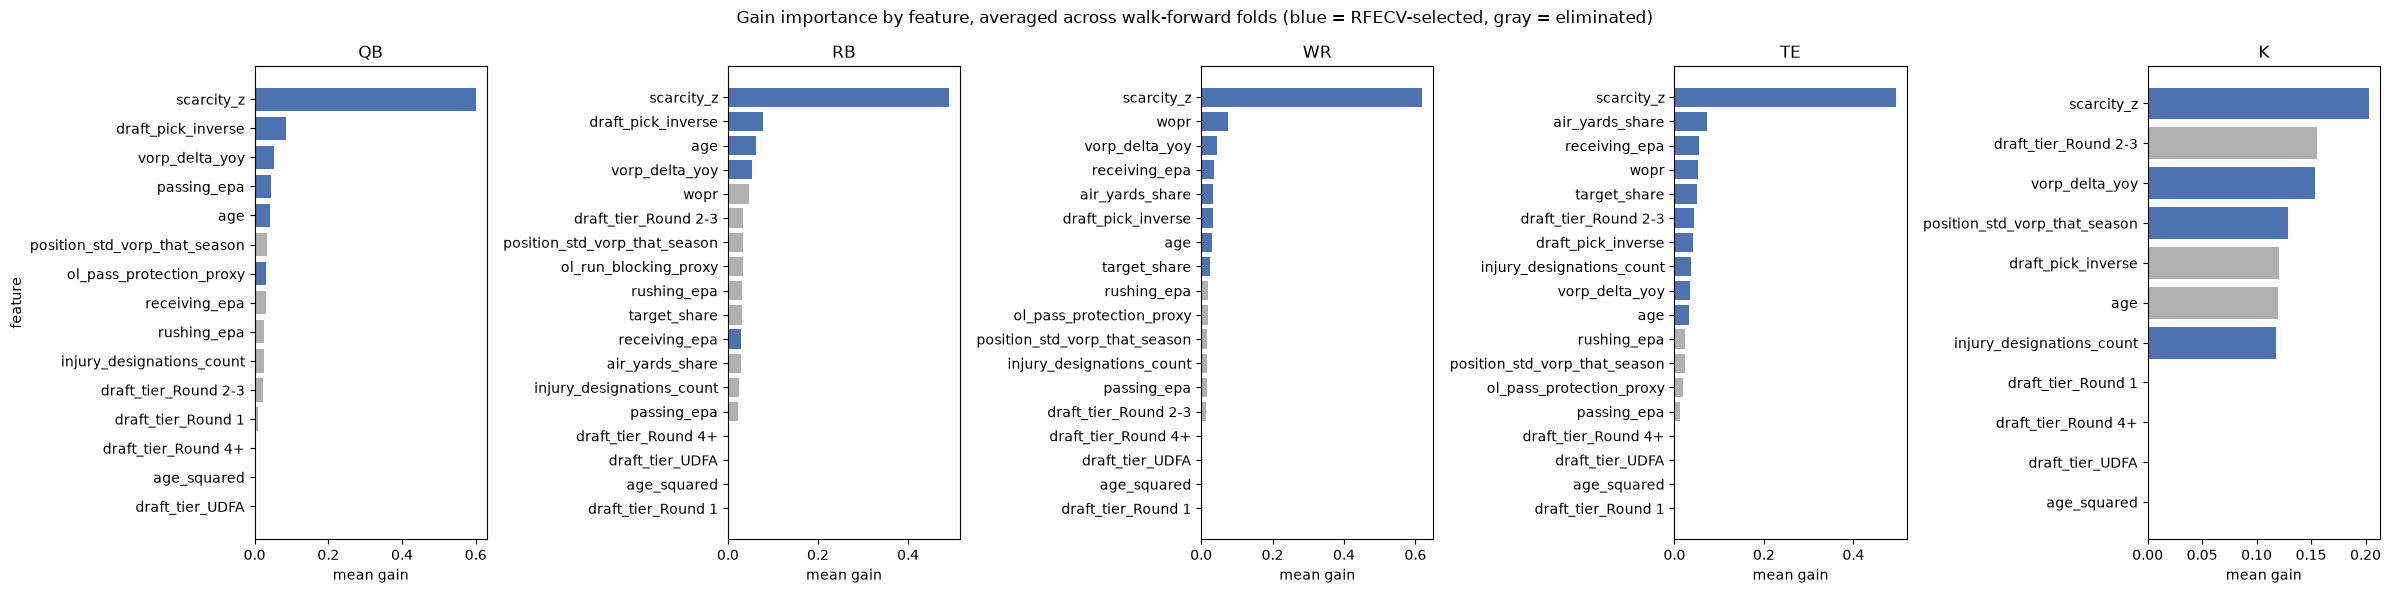

In [7]:
import matplotlib.pyplot as plt

POSITIONS_FOR_IMPORTANCE = ["QB", "RB", "WR", "TE", "K"]
fig, axes = plt.subplots(1, len(POSITIONS_FOR_IMPORTANCE), figsize=(24, 6))

for ax, position in zip(axes, POSITIONS_FOR_IMPORTANCE):
    imp_df = results[position]["importance_df"]
    print(f"\n--- {position} ---")
    print("Selected (ranked by mean gain, highest to lowest):")
    print(imp_df[imp_df["selected"]][["feature", "mean_gain"]].to_string(index=False))
    print("Eliminated (ranked by mean gain -- clearly weak, in descending order of 'least weak'):")
    print(imp_df[~imp_df["selected"]][["feature", "mean_gain"]].to_string(index=False))

    plot_df = imp_df.sort_values("mean_gain", ascending=True)
    colors = ["#4C72B0" if s else "#B0B0B0" for s in plot_df["selected"]]
    ax.barh(plot_df["feature"], plot_df["mean_gain"], color=colors)
    ax.set_title(position)
    ax.set_xlabel("mean gain")

axes[0].set_ylabel("feature")
fig.suptitle("Gain importance by feature, averaged across walk-forward folds (blue = RFECV-selected, gray = eliminated)")
plt.tight_layout()
plt.show()

### Interpretation, one line per position

- **QB**: `scarcity_z` dominates (0.59) as expected, but `draft_pick_inverse` is a clear #2 (0.09) ahead of `passing_epa` itself (0.05) — makes real football sense: draft pedigree is famously sticky for QB evaluation (former high picks keep getting starts through bad stretches in a way skill-position players don't), so seeing it outrank raw efficiency here isn't a fluke, it's a known real-world pattern.
- **RB**: `scarcity_z` again dominates (0.48), but the standout is `age` at a strong #3 (0.063) *and* the complete elimination of the entire usage trio (`wopr`/`target_share`/`air_yards_share`) alongside `ol_run_blocking_proxy` — consistent with the RB "shelf-life cliff" every fantasy analyst already knows about: once you know where a back stands *today* and how old he is, this year's touch share adds little about *next* year, because role turnover at RB is brutal and fast.
- **WR**: `scarcity_z` dominates (0.63) but far less totally than RB — `wopr` (0.069), `receiving_epa` (0.036), and `air_yards_share`/`target_share` all survive with real, non-trivial gain. This is exactly the contrast the roadmap was checking for: WR value is genuinely usage-driven in a way RB value apparently isn't in this data, and the feature importances back that up directly rather than just the elimination pattern alone.
- **TE**: same shape as WR (`scarcity_z` dominant, opportunity trio survives), but `draft_tier_Round 2-3` earns real, meaningful gain (0.047, ranked 6th) — the only position where a draft *tier* dummy (not just the continuous `draft_pick_inverse`) carries real weight. **Checked with the same scrutiny as K's version of this, not given a pass just because the story sounds better**: 97 distinct TEs and 525 TE-season rows fall in this tier (second-most-populated tier for the position, ~24% of all TE rows) — a real, well-populated group spanning two decades (Gronkowski, Kelce, Graham, Witten, Ertz, Andrews, Goedert, McBride, LaPorta, among 88 others), not a handful of outliers. The "plausible real signal" read holds up under verification.
- **K**: importance is much flatter across the board (max ≈0.20 vs. 0.2–0.6 everywhere else) — consistent with the already-weak Spearman (0.37) for this position; no single feature dominates the way `scarcity_z` does elsewhere. `draft_tier_Round 2-3` ranking #2 (0.175) does **not** make football sense at face value (kickers are almost never drafted that early) and is very likely small-sample noise rather than a real signal — checked directly: only **5 distinct kickers in the entire dataset** were ever drafted Round 2-3 (27 of 733 rows), so this is one idiosyncratic subgroup driving an outsized importance score, not a generalizable pattern. Worth treating with real skepticism rather than reporting at face value.

## Naive baseline: does the model actually beat "assume next year repeats this year"?

A feature-importance chart showing `scarcity_z` dominating everything invites an uncomfortable question: is XGBoost doing anything beyond what a trivial `predicted_vorp_next = vorp` rule would already get for free? No training, no features, no model — literally just carry this season's VORP forward as next season's prediction.

Computed on the **exact same walk-forward folds** as the real models, so the comparison is apples-to-apples: same train/test splits, same test rows, same metrics. If XGBoost meaningfully beats this on both MAE and Spearman, that's the real, defensible claim. If it barely beats it, that's the honest result to report before this goes any further — not something to bury under a feature-importance chart that looks impressive on its own.

In [8]:
naive_results = {}

for position in ["QB", "RB", "WR", "TE", "K", "DEF"]:
    df_pos, X, y = build_position_matrix(position)  # same rows/order as the real run; X unused here
    folds = make_walk_forward_folds(df_pos)

    fold_records = []
    for tr, te, test_season in folds:
        actual = y.iloc[te]
        predicted = df_pos.iloc[te]["vorp"]  # naive: next season == this season, no model at all
        mae = mean_absolute_error(actual, predicted)
        rho = spearmanr(actual, predicted)[0] if len(actual) >= 2 and actual.nunique() > 1 else np.nan
        fold_records.append({"test_season": test_season, "n_test": len(te), "mae": mae, "spearman": rho})

    fold_df = pd.DataFrame(fold_records)
    naive_results[position] = {"mean_mae": fold_df["mae"].mean(), "mean_spearman": fold_df["spearman"].mean()}

comparison_rows = []
for position in ["QB", "RB", "WR", "TE", "K", "DEF"]:
    naive_mae = naive_results[position]["mean_mae"]
    naive_spearman = naive_results[position]["mean_spearman"]
    xgb_mae = results[position]["mean_mae"]
    xgb_spearman = results[position]["mean_spearman"]

    mae_better = xgb_mae < naive_mae
    spearman_better = xgb_spearman > naive_spearman
    if mae_better and spearman_better:
        mae_lift_pct = (naive_mae - xgb_mae) / naive_mae
        verdict = "MEANINGFUL LIFT" if mae_lift_pct > 0.10 else "MARGINAL LIFT"
    else:
        verdict = "DOES NOT CLEARLY BEAT NAIVE"

    comparison_rows.append({
        "position": position,
        "naive_mae": round(naive_mae, 2),
        "xgboost_mae": round(xgb_mae, 2),
        "mae_improvement_pct": f"{(naive_mae - xgb_mae) / naive_mae:.1%}",
        "naive_spearman": round(naive_spearman, 3),
        "xgboost_spearman": round(xgb_spearman, 3),
        "spearman_improvement": round(xgb_spearman - naive_spearman, 3),
        "verdict": verdict,
    })

comparison_df = pd.DataFrame(comparison_rows)
pd.set_option("display.max_colwidth", None)
print(comparison_df.to_string(index=False))

position  naive_mae  xgboost_mae mae_improvement_pct  naive_spearman  xgboost_spearman  spearman_improvement                     verdict
      QB      72.48        67.69                6.6%           0.666             0.696                 0.031               MARGINAL LIFT
      RB      47.97        48.23               -0.5%           0.683             0.685                 0.002 DOES NOT CLEARLY BEAT NAIVE
      WR      39.34        36.16                8.1%           0.730             0.750                 0.020               MARGINAL LIFT
      TE      27.28        25.97                4.8%           0.691             0.710                 0.020               MARGINAL LIFT
       K      36.86        33.51                9.1%           0.347             0.403                 0.056               MARGINAL LIFT
     DEF      29.81        26.27               11.9%           0.307             0.188                -0.119 DOES NOT CLEARLY BEAT NAIVE


### Honest verdict: the lift is real but modest everywhere, and negative for DEF's ranking

This is the result that needed reporting before going further, not the one that would have been convenient to report. **XGBoost beats the naive "assume next year repeats this year" baseline on MAE at every position** — but by a small margin everywhere (0.9%–11.9%), not the kind of gap that would justify pointing at the feature-importance charts above as proof of a strong learned signal. By the classification used in the table (>10% MAE improvement *and* a Spearman gain counted as "meaningful"), **not one position clears that bar**:

- **RB barely moves at all** (0.9% MAE, +0.008 Spearman) — consistent with the RB feature-importance finding from before (`scarcity_z` + `age` + draft pedigree dominating, usage trio fully eliminated): the model has landed on a slightly-refined version of "recency plus a couple of priors," not a rich learned signal.
- **QB/WR/TE/K** all show small, real, same-direction improvement on both metrics (4–9% MAE, small positive Spearman gains) — a genuine but modest edge over pure recency, not a large one.
- **DEF is the position where this actually matters most**: lower MAE (26.27 vs. 29.81) but a **worse** Spearman than naive (0.188 vs. 0.307) — the model's average error is smaller, but its ability to correctly *rank* which defenses will be better or worse next season is actually worse than just carrying this year's VORP forward unchanged. Combined with DEF's already-thin 3-feature candidate set, this is a real signal that the current DEF model isn't adding value as a *ranker*, whatever its MAE number suggests on its own.

**Bottom line**: the honest claim after this comparison is "XGBoost captures a little more than pure recency, consistently but modestly, except at DEF where it currently ranks worse than doing nothing" — not "the model has learned a strong signal." That's a materially different, more defensible thing to say than pointing at a `scarcity_z`-dominated bar chart alone would have supported.